# Leaderboard Integration
Objective: Integrate LLM benchmark scores from Open LLM Leaderboard to add performance metrics for the RL reward function.
Outputs:

data/processed/features_with_scores.parquet
data/cache/leaderboard_scores.json
data/processed/leaderboard_summary.json

## 1. Setup & Load Features

In [8]:
# Setup & Load Features
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Add colab_src to path
BASE_DIR = Path("/content/drive/MyDrive/llm-recommender-colab")
sys.path.insert(0, str(BASE_DIR / "colab_src"))

from utils import PathManager, save_json, validate_dataframe
from leaderboard_client import LeaderboardClient, PerformanceScorer

# Initialize paths
paths = PathManager(BASE_DIR)

# Load features from Sprint 3
features_file = paths.PROCESSED_DIR / "features.parquet"
df = pd.read_parquet(features_file)

print(f"✅ Loaded {len(df)} models from Sprint 3")
print(f"   Columns: {len(df.columns)}")
print(f"\nSample data:")
display(df[['model_id', 'cost_score', 'popularity_score', 'recency_score']].head())


✅ Loaded 95 models from Sprint 3
   Columns: 19

Sample data:


,model_id,cost_score,popularity_score,recency_score
0,openai-community/gpt2,0.014539,1.000000,0.5
1,Qwen/Qwen2.5-3B-Instruct,0.008575,0.824914,0.5
2,openai/gpt-oss-20b,0.059265,0.985242,0.5
3,Qwen/Qwen2.5-7B-Instruct,0.020502,0.885193,0.5
4,Qwen/Qwen3-0.6B,0.001419,0.868748,0.5


## 2. Initialize Leaderboard Client

In [13]:
# Initialize Leaderboard Client
print("Initializing leaderboard client...")

# Cache file for leaderboard data
cache_file = paths.CACHE_DIR / "leaderboard_scores.json"

# Initialize client
client = LeaderboardClient(
    cache_file=cache_file,
    rate_limit_delay=1.0
)

print(f"✅ Leaderboard client initialized")
print(f"   Cache file: {cache_file}")

Initializing leaderboard client...
✅ Leaderboard client initialized
   Cache file: /content/drive/MyDrive/llm-recommender-colab/data/cache/leaderboard_scores.json


### Diagnostic cell: Inspect Leaderboard Structure

In [3]:
# DIAGNOSTIC CELL: Inspect Leaderboard Structure

print("="*60)
print("LEADERBOARD STRUCTURE INSPECTION")
print("="*60)

# Fetch leaderboard
from datasets import load_dataset

dataset = load_dataset(
    "open-llm-leaderboard/contents",
    split="train"
)

df_leaderboard = dataset.to_pandas()

print(f"\nDataset shape: {df_leaderboard.shape}")
print(f"\nAll columns ({len(df_leaderboard.columns)}):")
for i, col in enumerate(df_leaderboard.columns):
    print(f"  {i+1}. {col}")

print(f"\nSample data (first 3 rows):")
display(df_leaderboard.head(3))

print(f"\nColumn data types:")
print(df_leaderboard.dtypes)

# Try to identify the model identifier column
print(f"\n{'='*60}")
print("IDENTIFYING MODEL COLUMN")
print(f"{'='*60}")

# Check for columns with 'model' in name
model_cols = [col for col in df_leaderboard.columns if 'model' in col.lower()]
print(f"\nColumns containing 'model': {model_cols}")

# Show sample values from each model-related column
for col in model_cols[:3]:  # Show first 3
    print(f"\nSample values from '{col}':")
    print(df_leaderboard[col].head(5).tolist())

LEADERBOARD STRUCTURE INSPECTION


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.11M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4576 [00:00<?, ? examples/s]


Dataset shape: (4576, 36)

All columns (36):
  1. eval_name
  2. Precision
  3. Type
  4. T
  5. Weight type
  6. Architecture
  7. Model
  8. fullname
  9. Model sha
  10. Average ⬆️
  11. Hub License
  12. Hub ❤️
  13. #Params (B)
  14. Available on the hub
  15. MoE
  16. Flagged
  17. Chat Template
  18. CO₂ cost (kg)
  19. IFEval Raw
  20. IFEval
  21. BBH Raw
  22. BBH
  23. MATH Lvl 5 Raw
  24. MATH Lvl 5
  25. GPQA Raw
  26. GPQA
  27. MUSR Raw
  28. MUSR
  29. MMLU-PRO Raw
  30. MMLU-PRO
  31. Merged
  32. Official Providers
  33. Upload To Hub Date
  34. Submission Date
  35. Generation
  36. Base Model

Sample data (first 3 rows):


,eval_name,Precision,Type,T,Weight type,Architecture,Model,fullname,Model sha,Average ⬆️,...,MUSR Raw,MUSR,MMLU-PRO Raw,MMLU-PRO,Merged,Official Providers,Upload To Hub Date,Submission Date,Generation,Base Model
0,0-hero_Matter-0.2-7B-DPO_bfloat16,bfloat16,"💬 chat models (RLHF, DPO, IFT, ...)",💬,Original,MistralForCausalLM,"<a target=""_blank"" href=""https://huggingface.c...",0-hero/Matter-0.2-7B-DPO,26a66f0d862e2024ce4ad0a09c37052ac36e8af6,8.906361,...,0.381375,5.871875,0.116356,1.817376,False,False,2024-04-13,2024-08-05,0,0-hero/Matter-0.2-7B-DPO
1,01-ai_Yi-1.5-34B_bfloat16,bfloat16,🟢 pretrained,🟢,Original,LlamaForCausalLM,"<a target=""_blank"" href=""https://huggingface.c...",01-ai/Yi-1.5-34B,4b486f81c935a2dadde84c6baa1e1370d40a098f,25.646494,...,0.423604,11.217188,0.466589,40.732122,False,True,2024-05-11,2024-06-12,0,01-ai/Yi-1.5-34B
2,01-ai_Yi-1.5-34B-32K_bfloat16,bfloat16,🟢 pretrained,🟢,Original,LlamaForCausalLM,"<a target=""_blank"" href=""https://huggingface.c...",01-ai/Yi-1.5-34B-32K,2c03a29761e4174f20347a60fbe229be4383d48b,26.727913,...,0.439823,14.077865,0.470911,41.212323,False,True,2024-05-15,2024-06-12,0,01-ai/Yi-1.5-34B-32K



Column data types:
eval_name                object
Precision                object
Type                     object
T                        object
Weight type              object
Architecture             object
Model                    object
fullname                 object
Model sha                object
Average ⬆️              float64
Hub License              object
Hub ❤️                    int64
#Params (B)             float64
Available on the hub       bool
MoE                        bool
Flagged                    bool
Chat Template              bool
CO₂ cost (kg)           float64
IFEval Raw              float64
IFEval                  float64
BBH Raw                 float64
BBH                     float64
MATH Lvl 5 Raw          float64
MATH Lvl 5              float64
GPQA Raw                float64
GPQA                    float64
MUSR Raw                float64
MUSR                    float64
MMLU-PRO Raw            float64
MMLU-PRO                float64
Merged              

In [16]:
# CELL 2.5: Force Reload Leaderboard Module

print("Reloading leaderboard_client module...")

import importlib
import sys

# Remove cached module
if 'leaderboard_client' in sys.modules:
    del sys.modules['leaderboard_client']

# Re-import with new structure
from leaderboard_client import LeaderboardClient, PerformanceScorer

print("✅ Module reloaded with NEW ModelScores structure")

# Clear cache file as well
cache_file = paths.CACHE_DIR / "leaderboard_scores.json"
if cache_file.exists():
    cache_file.unlink()
    print(f"✅ Cleared cache: {cache_file}")

# Re-initialize client with reloaded module
client = LeaderboardClient(
    cache_file=cache_file,
    rate_limit_delay=1.0
)

print("✅ Client re-initialized")

Reloading leaderboard_client module...
✅ Module reloaded with NEW ModelScores structure
✅ Cleared cache: /content/drive/MyDrive/llm-recommender-colab/data/cache/leaderboard_scores.json
✅ Client re-initialized


## 3. Fetch Leaderboard Data
Note: This will download the Open LLM Leaderboard dataset from HuggingFace. May take 1-2 minutes on first run.

In [17]:
# CELL 3: Fetch Leaderboard Data (FORCE FRESH FETCH)
print("="*60)
print("FETCHING LEADERBOARD DATA")
print("="*60)

# Install datasets library if needed
try:
    from datasets import load_dataset
except ImportError:
    print("Installing datasets library...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])
    from datasets import load_dataset

# Get list of model IDs
model_ids = df['model_id'].tolist()

print(f"\nFetching scores for {len(model_ids)} models...")
print("⚠️  FORCING FRESH FETCH (ignoring cache due to structure change)")
print("This may take 1-2 minutes...\n")

# Fetch scores WITHOUT using cache
model_scores = client.fetch_batch_scores(
    model_ids=model_ids,
    use_cache=False  # Force fresh fetch
)

print(f"\n✅ Scores fetched for {len(model_scores)} models")

# Count models with scores
models_with_scores = sum(1 for s in model_scores.values() if s.average_score is not None)
print(f"   Models with benchmark scores: {models_with_scores}/{len(model_scores)} ({models_with_scores/len(model_scores)*100:.1f}%)")

FETCHING LEADERBOARD DATA

Fetching scores for 95 models...
⚠️  FORCING FRESH FETCH (ignoring cache due to structure change)
This may take 1-2 minutes...

Fetching Open LLM Leaderboard data...
Loading leaderboard dataset from HuggingFace...
✅ Loaded 4576 leaderboard entries

Available columns: ['eval_name', 'Precision', 'Type', 'T', 'Weight type', 'Architecture', 'Model', 'fullname', 'Model sha', 'Average ⬆️']...


Parsing leaderboard scores:   0%|          | 0/95 [00:00<?, ?it/s]


✅ Scores fetched for 95 models
   Models with benchmark scores: 46/95 (48.4%)


## 4. Parse Benchmark Scores
Extract individual benchmark scores for each model.

Parsing individual benchmark scores...
✅ Parsed 95 model scores

Benchmark Coverage:
  ifeval         :  46/95 ( 48.4%)
  bbh            :  46/95 ( 48.4%)
  math           :  46/95 ( 48.4%)
  gpqa           :  46/95 ( 48.4%)
  musr           :  46/95 ( 48.4%)
  mmlu_pro       :  46/95 ( 48.4%)

Sample Benchmark Scores (NEW leaderboard):


,model_id,ifeval,bbh,math,average_score
0,openai-community/gpt2,17.925327,2.674981,0.226586,6.510807
1,Qwen/Qwen2.5-3B-Instruct,64.749199,25.801394,36.782477,27.161757
3,Qwen/Qwen2.5-7B-Instruct,75.852516,34.892117,50.000000,35.200109
6,Qwen/Qwen2.5-1.5B-Instruct,44.755693,19.809786,22.054381,18.430509
7,meta-llama/Llama-3.1-8B-Instruct,49.217077,29.379192,15.558912,23.763729
8,dphn/dolphin-2.9.1-yi-1.5-34b,38.525889,44.174089,18.655589,28.307204
15,mistralai/Mistral-7B-Instruct-v0.2,54.962278,22.910602,3.021148,18.507892
16,meta-llama/Llama-3.2-1B-Instruct,56.983138,8.742521,7.024169,14.443126
17,meta-llama/Llama-3.2-1B,14.777900,4.366030,1.208459,4.195140
21,Gensyn/Qwen2.5-0.5B-Instruct,30.832192,7.347825,4.078550,8.550830


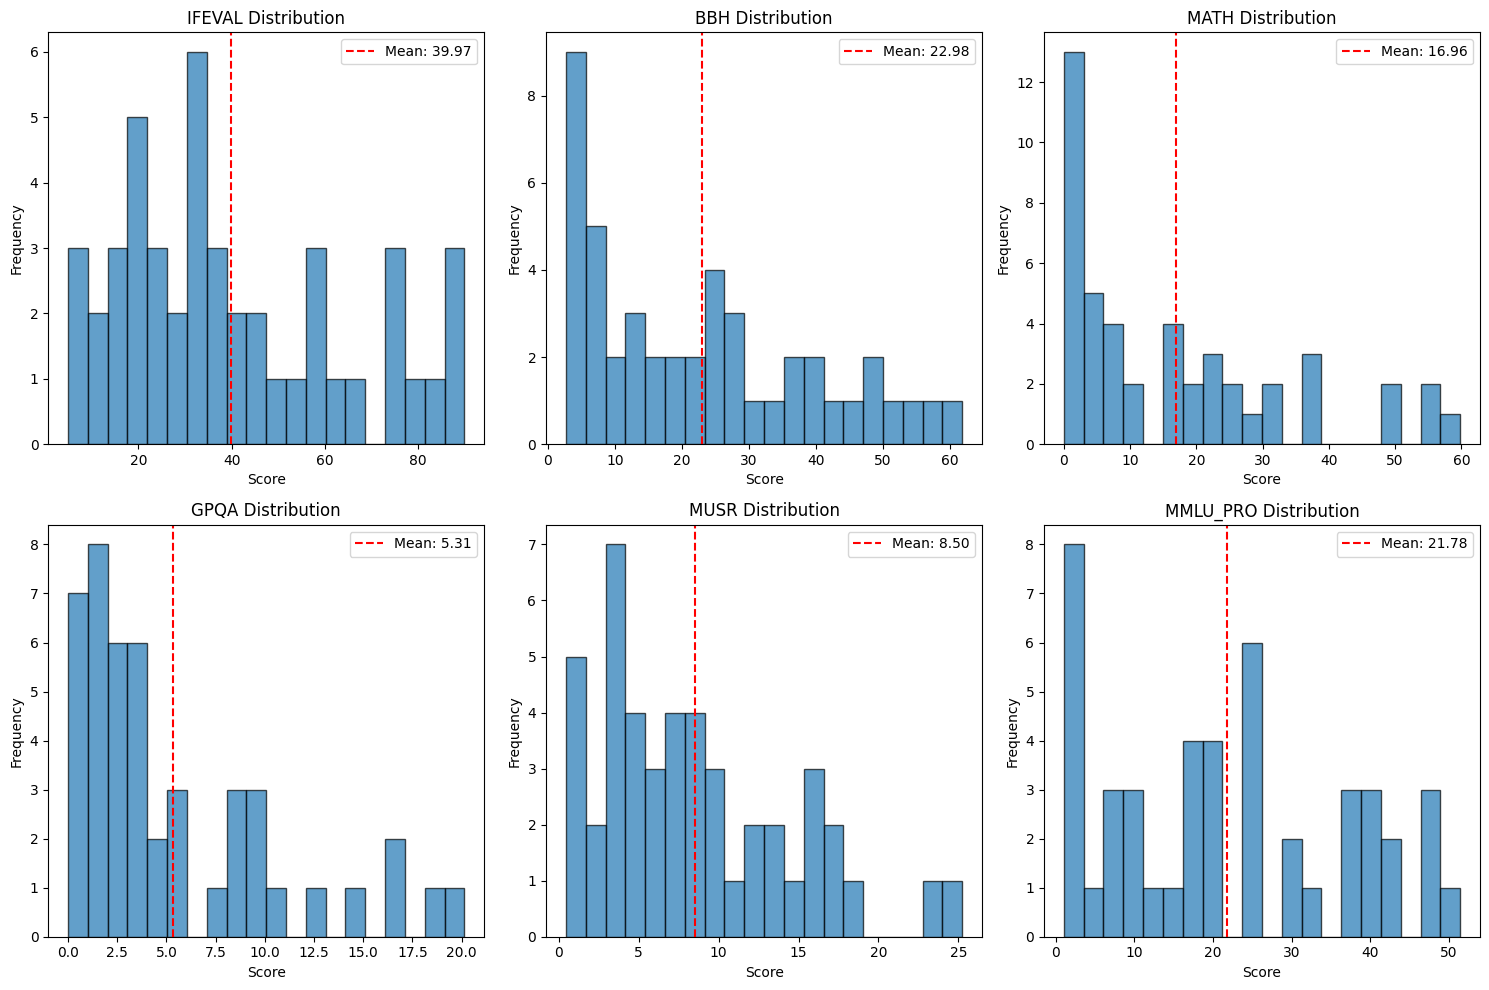

In [18]:
# Parse Benchmark Scores (UPDATED FOR NEW LEADERBOARD)
print("Parsing individual benchmark scores...")

# Extract scores into DataFrame
scores_data = []

for model_id, scores in model_scores.items():
    scores_data.append({
        'model_id': model_id,
        # NEW benchmarks
        'ifeval': scores.ifeval,
        'bbh': scores.bbh,
        'math': scores.math,
        'gpqa': scores.gpqa,
        'musr': scores.musr,
        'mmlu_pro': scores.mmlu_pro,
        # Legacy benchmarks (likely None)
        'mmlu': scores.mmlu,
        'gsm8k': scores.gsm8k,
        'truthfulqa': scores.truthfulqa,
        'hellaswag': scores.hellaswag,
        'arc': scores.arc,
        'winogrande': scores.winogrande,
        'benchmark_count': scores.benchmark_count,
        'average_score': scores.average_score
    })

df_scores = pd.DataFrame(scores_data)

print(f"✅ Parsed {len(df_scores)} model scores")
print(f"\nBenchmark Coverage:")

# NEW benchmarks
new_benchmarks = ['ifeval', 'bbh', 'math', 'gpqa', 'musr', 'mmlu_pro']
for benchmark in new_benchmarks:
    coverage = df_scores[benchmark].notna().sum()
    pct = (coverage / len(df_scores)) * 100
    print(f"  {benchmark:15s}: {coverage:3d}/{len(df_scores)} ({pct:5.1f}%)")

# Show sample scores
print(f"\nSample Benchmark Scores (NEW leaderboard):")
display(df_scores[df_scores['average_score'].notna()][['model_id', 'ifeval', 'bbh', 'math', 'average_score']].head(10))

# Visualize benchmark score distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, benchmark in enumerate(new_benchmarks):
    valid_scores = df_scores[benchmark].dropna()
    if len(valid_scores) > 0:
        axes[idx].hist(valid_scores, bins=20, edgecolor='black', alpha=0.7)
        axes[idx].set_xlabel('Score')
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'{benchmark.upper()} Distribution')
        axes[idx].axvline(valid_scores.mean(), color='red', linestyle='--',
                         label=f'Mean: {valid_scores.mean():.2f}')
        axes[idx].legend()
    else:
        axes[idx].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[idx].set_title(f'{benchmark.upper()} Distribution')

plt.tight_layout()
plt.show()

## 5. Calculate Composite Performance Score
Weighted average across all available benchmarks.

CALCULATING COMPOSITE PERFORMANCE SCORES

Benchmark Weights:
  ifeval         : 0.20
  bbh            : 0.20
  math           : 0.20
  gpqa           : 0.15
  musr           : 0.15
  mmlu_pro       : 0.10
  mmlu           : 0.00
  gsm8k          : 0.00
  truthfulqa     : 0.00
  hellaswag      : 0.00
  arc            : 0.00
  winogrande     : 0.00

✅ Composite scores calculated

Performance Score Statistics:
       composite_score  performance_score
count        46.000000          46.000000
mean         20.233282           0.358172
std          12.619345           0.263114
min           3.054815           0.000000
25%           9.366566           0.131600
50%          17.237754           0.295715
75%          28.093868           0.522066
max          51.016297           1.000000


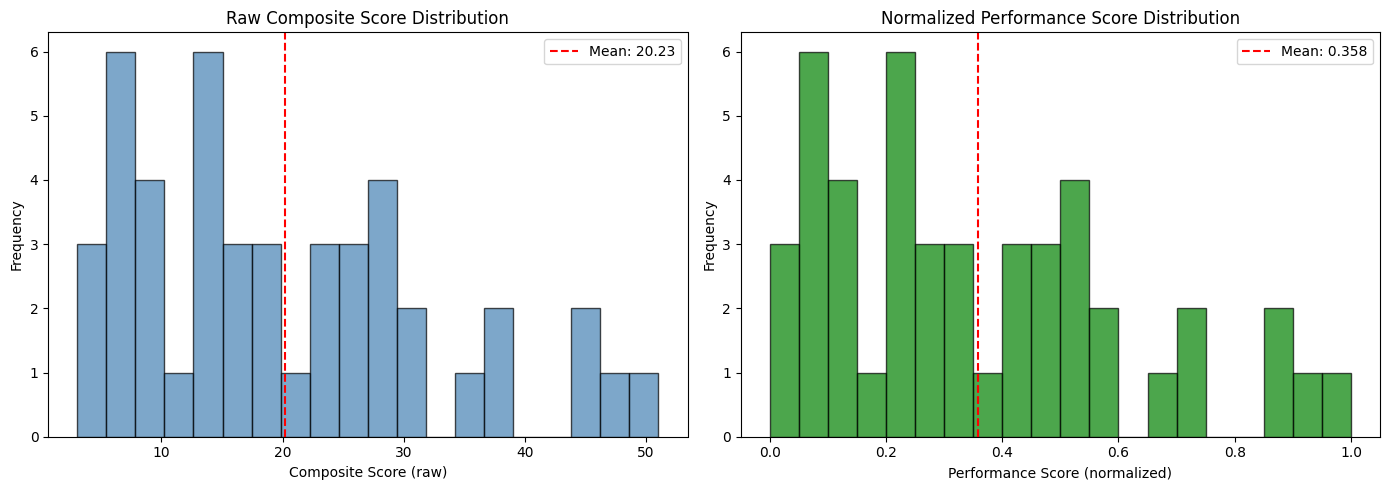

In [19]:

# CELL 5: Calculate Composite Performance Score
print("="*60)
print("CALCULATING COMPOSITE PERFORMANCE SCORES")
print("="*60)

# Calculate composite scores using weighted average
print("\nBenchmark Weights:")
for benchmark, weight in PerformanceScorer.DEFAULT_WEIGHTS.items():
    print(f"  {benchmark:15s}: {weight:.2f}")

# Calculate composite scores
df_scores['composite_score'] = df_scores.apply(
    lambda row: PerformanceScorer.calculate_composite_score(
        model_scores[row['model_id']]
    ),
    axis=1
)

# Normalize to [0, 1]
df_scores['performance_score'] = PerformanceScorer.normalize_performance_scores(
    df_scores['composite_score']
)

print(f"\n✅ Composite scores calculated")
print(f"\nPerformance Score Statistics:")
print(df_scores[['composite_score', 'performance_score']].describe())

# Visualize composite scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw composite scores
valid_composite = df_scores['composite_score'].dropna()
if len(valid_composite) > 0:
    axes[0].hist(valid_composite, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Composite Score (raw)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Raw Composite Score Distribution')
    axes[0].axvline(valid_composite.mean(), color='red', linestyle='--',
                   label=f'Mean: {valid_composite.mean():.2f}')
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'No data', ha='center', va='center')

# Normalized performance scores
valid_perf = df_scores['performance_score'].dropna()
if len(valid_perf) > 0:
    axes[1].hist(valid_perf, bins=20, edgecolor='black', alpha=0.7, color='green')
    axes[1].set_xlabel('Performance Score (normalized)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Normalized Performance Score Distribution')
    axes[1].axvline(valid_perf.mean(), color='red', linestyle='--',
                   label=f'Mean: {valid_perf.mean():.3f}')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No data', ha='center', va='center')

plt.tight_layout()
plt.show()

## 6. Merge with Features

In [20]:

# CELL 6: Merge with Features
print("="*60)
print("MERGING SCORES WITH FEATURES")
print("="*60)

# Merge scores with features
df_enhanced = df.merge(df_scores, on='model_id', how='left')

print(f"✅ Merged scores with features")
print(f"   Shape: {df_enhanced.shape}")
print(f"   Total columns: {len(df_enhanced.columns)}")

# Show sample merged data
print(f"\nSample Enhanced Features:")
display_cols = ['model_id', 'cost_score', 'popularity_score', 'recency_score',
                'performance_score', 'average_score']
display(df_enhanced[display_cols].head(10))

MERGING SCORES WITH FEATURES
✅ Merged scores with features
   Shape: (95, 35)
   Total columns: 35

Sample Enhanced Features:


,model_id,cost_score,popularity_score,recency_score,performance_score,average_score
0,openai-community/gpt2,0.014539,1.000000,0.5,0.078348,6.510807
1,Qwen/Qwen2.5-3B-Instruct,0.008575,0.824914,0.5,0.552628,27.161757
2,openai/gpt-oss-20b,0.059265,0.985242,0.5,NaN,NaN
3,Qwen/Qwen2.5-7B-Instruct,0.020502,0.885193,0.5,0.726342,35.200109
4,Qwen/Qwen3-0.6B,0.001419,0.868748,0.5,NaN,NaN
5,Qwen/Qwen3-4B-Instruct-2507,0.011557,0.800554,0.5,NaN,NaN
6,Qwen/Qwen2.5-1.5B-Instruct,0.004103,0.791132,0.5,0.351617,18.430509
7,meta-llama/Llama-3.1-8B-Instruct,0.023484,0.934591,0.5,0.447979,23.763729
8,dphn/dolphin-2.9.1-yi-1.5-34b,0.024975,0.616633,0.5,0.532397,28.307204
9,facebook/opt-125m,0.521433,0.712170,0.5,NaN,NaN


## 7. Quality Validation
Analyze score coverage and distributions.

QUALITY VALIDATION

Feature Completeness:
  cost_score               :  86/95 ( 90.5%)
  popularity_score         :  95/95 (100.0%)
  recency_score            :  95/95 (100.0%)
  diversity_score          :  95/95 (100.0%)
  performance_score        :  46/95 ( 48.4%)

FEATURE CORRELATIONS

Models with all features: 46/95

Correlation Matrix:


,cost_score,popularity_score,recency_score,diversity_score,performance_score
cost_score,1.000000,-0.132592,NaN,-0.040808,0.472147
popularity_score,-0.132592,1.000000,NaN,0.179053,0.000242
recency_score,NaN,NaN,NaN,NaN,NaN
diversity_score,-0.040808,0.179053,NaN,1.000000,-0.132077
performance_score,0.472147,0.000242,NaN,-0.132077,1.000000


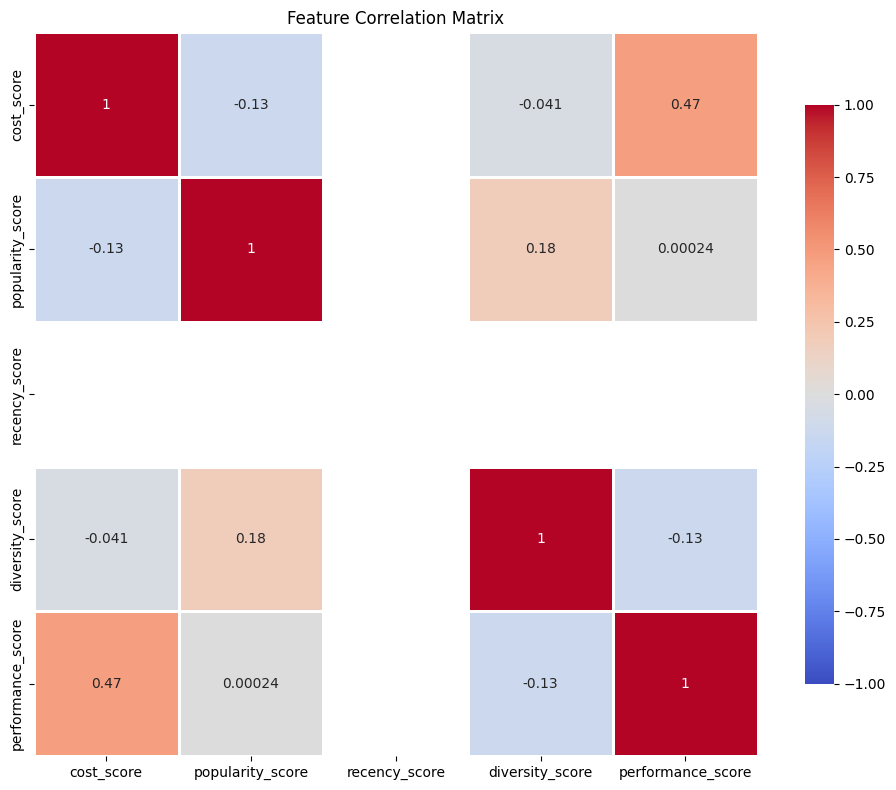


PERFORMANCE vs COST ANALYSIS

Models with both cost and performance: 46


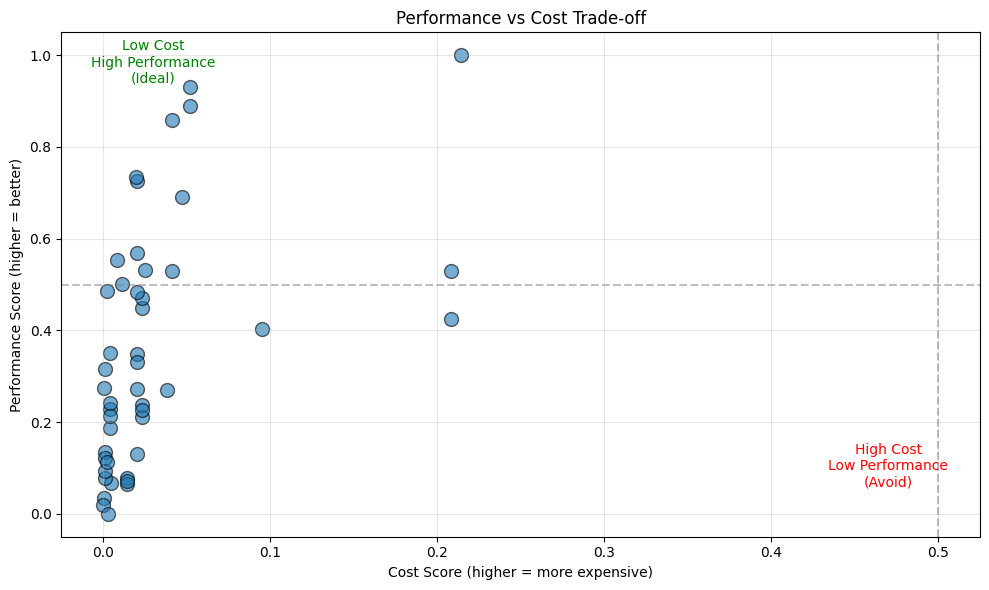


Top 5 Best Value Models (High Performance, Low Cost):
  meta-llama/Llama-3.3-70B-Instruct             | Perf: 0.931 | Cost: 0.052 | Value: 0.879
  meta-llama/Llama-3.1-70B-Instruct             | Perf: 0.889 | Cost: 0.052 | Value: 0.838
  Qwen/Qwen2.5-14B-Instruct                     | Perf: 0.859 | Cost: 0.041 | Value: 0.817
  Qwen/Qwen2.5-72B-Instruct                     | Perf: 1.000 | Cost: 0.214 | Value: 0.786
  google/gemma-2-27b-it                         | Perf: 0.735 | Cost: 0.020 | Value: 0.715


In [21]:
# CELL 7: Quality Validation
print("="*60)
print("QUALITY VALIDATION")
print("="*60)

# Feature completeness
all_features = ['cost_score', 'popularity_score', 'recency_score',
                'diversity_score', 'performance_score']

print("\nFeature Completeness:")
for feature in all_features:
    if feature in df_enhanced.columns:
        non_null = df_enhanced[feature].notna().sum()
        pct = (non_null / len(df_enhanced)) * 100
        print(f"  {feature:25s}: {non_null:3d}/{len(df_enhanced)} ({pct:5.1f}%)")

# Correlation analysis
print(f"\n{'='*60}")
print("FEATURE CORRELATIONS")
print(f"{'='*60}")

# Calculate correlations for models with all features
df_complete = df_enhanced[all_features].dropna()

if len(df_complete) > 10:
    corr_matrix = df_complete.corr()

    print(f"\nModels with all features: {len(df_complete)}/{len(df_enhanced)}")
    print(f"\nCorrelation Matrix:")
    display(corr_matrix)

    # Visualize correlations
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1)
    plt.title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()
else:
    print(f"\n⚠️  Too few models with complete features ({len(df_complete)}) for correlation analysis")

# Performance vs Cost analysis
print(f"\n{'='*60}")
print("PERFORMANCE vs COST ANALYSIS")
print(f"{'='*60}")

df_analysis = df_enhanced[['model_id', 'cost_score', 'performance_score']].dropna()

if len(df_analysis) > 0:
    print(f"\nModels with both cost and performance: {len(df_analysis)}")

    # Scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(df_analysis['cost_score'], df_analysis['performance_score'],
               alpha=0.6, s=100, edgecolors='black')
    plt.xlabel('Cost Score (higher = more expensive)')
    plt.ylabel('Performance Score (higher = better)')
    plt.title('Performance vs Cost Trade-off')
    plt.grid(True, alpha=0.3)

    # Add quadrant lines
    plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

    # Label quadrants
    plt.text(0.1, 0.9, 'Low Cost\nHigh Performance\n(Ideal)',
            transform=plt.gca().transAxes, ha='center', fontsize=10, color='green')
    plt.text(0.9, 0.1, 'High Cost\nLow Performance\n(Avoid)',
            transform=plt.gca().transAxes, ha='center', fontsize=10, color='red')

    plt.tight_layout()
    plt.show()

    # Find best value models (high performance, low cost)
    df_analysis['value_score'] = df_analysis['performance_score'] - df_analysis['cost_score']
    top_value = df_analysis.nlargest(5, 'value_score')

    print(f"\nTop 5 Best Value Models (High Performance, Low Cost):")
    for idx, row in top_value.iterrows():
        model_id = df_enhanced.loc[idx, 'model_id']
        print(f"  {model_id:45s} | Perf: {row['performance_score']:.3f} | Cost: {row['cost_score']:.3f} | Value: {row['value_score']:.3f}")
else:
    print("\n⚠️  No models with both cost and performance scores")


## 8. Save Enhanced Dataset

In [24]:
# CELL 8: Save Enhanced Dataset (FIXED)
print("="*60)
print("SAVING ENHANCED DATASET")
print("="*60)

# Save enhanced features
enhanced_file = paths.PROCESSED_DIR / "features_with_scores.parquet"
df_enhanced.to_parquet(enhanced_file, index=False)

print(f"✅ Enhanced features saved to: {enhanced_file}")
print(f"   File size: {enhanced_file.stat().st_size / 1024:.2f} KB")

# Define benchmark list (NEW leaderboard benchmarks)
new_benchmarks = ['ifeval', 'bbh', 'math', 'gpqa', 'musr', 'mmlu_pro']
legacy_benchmarks = ['mmlu', 'gsm8k', 'truthfulqa', 'hellaswag', 'arc', 'winogrande']
all_benchmarks = new_benchmarks + legacy_benchmarks

# Save leaderboard summary
summary = {
    'metadata': {
        'created_at': pd.Timestamp.now().isoformat(),
        'total_models': len(df_enhanced),
        'models_with_scores': int(df_enhanced['performance_score'].notna().sum())
    },
    'coverage': {
        benchmark: {
            'count': int(df_enhanced[benchmark].notna().sum()),
            'percentage': float((df_enhanced[benchmark].notna().sum() / len(df_enhanced)) * 100)
        }
        for benchmark in all_benchmarks + ['performance_score']
        if benchmark in df_enhanced.columns
    },
    'statistics': {
        'mean_performance': float(df_enhanced['performance_score'].mean()) if df_enhanced['performance_score'].notna().sum() > 0 else None,
        'std_performance': float(df_enhanced['performance_score'].std()) if df_enhanced['performance_score'].notna().sum() > 0 else None,
        'mean_composite': float(df_enhanced['composite_score'].mean()) if df_enhanced['composite_score'].notna().sum() > 0 else None
    },
    'benchmark_weights': PerformanceScorer.DEFAULT_WEIGHTS,
    'leaderboard_version': 'new_2024',  # Indicate which leaderboard structure
    'new_benchmarks': new_benchmarks,
    'legacy_benchmarks': legacy_benchmarks
}

summary_file = paths.PROCESSED_DIR / "leaderboard_summary.json"
save_json(summary, summary_file)
print(f"✅ Summary saved to: {summary_file}")

# Print final statistics
print(f"\n{'='*60}")
print("SPRINT 4 COMPLETE")
print(f"{'='*60}")

print(f"\n✅ Artifacts Created:")
print(f"   1. Enhanced features: {enhanced_file}")
print(f"   2. Leaderboard cache: {cache_file}")
print(f"   3. Summary: {summary_file}")

print(f"\n📊 Final Statistics:")
print(f"   Total models: {len(df_enhanced)}")
print(f"   Models with performance scores: {summary['metadata']['models_with_scores']} ({summary['metadata']['models_with_scores']/len(df_enhanced)*100:.1f}%)")

if summary['statistics']['mean_performance']:
    print(f"   Mean performance score: {summary['statistics']['mean_performance']:.3f}")

# Show NEW benchmark coverage
print(f"\n📈 NEW Benchmark Coverage:")
for benchmark in new_benchmarks:
    if benchmark in summary['coverage']:
        cov = summary['coverage'][benchmark]
        print(f"   {benchmark:15s}: {cov['count']:3d}/{len(df_enhanced)} ({cov['percentage']:5.1f}%)")

print(f"\n   Total features: {len([c for c in df_enhanced.columns if c.endswith('_score')])}")

print(f"\nNext: Sprint 5 - RL Environment Design")

SAVING ENHANCED DATASET
✅ Enhanced features saved to: /content/drive/MyDrive/llm-recommender-colab/data/processed/features_with_scores.parquet
   File size: 53.75 KB
✅ Summary saved to: /content/drive/MyDrive/llm-recommender-colab/data/processed/leaderboard_summary.json

SPRINT 4 COMPLETE

✅ Artifacts Created:
   1. Enhanced features: /content/drive/MyDrive/llm-recommender-colab/data/processed/features_with_scores.parquet
   2. Leaderboard cache: /content/drive/MyDrive/llm-recommender-colab/data/cache/leaderboard_scores.json
   3. Summary: /content/drive/MyDrive/llm-recommender-colab/data/processed/leaderboard_summary.json

📊 Final Statistics:
   Total models: 95
   Models with performance scores: 46 (48.4%)
   Mean performance score: 0.358

📈 NEW Benchmark Coverage:
   ifeval         :  46/95 ( 48.4%)
   bbh            :  46/95 ( 48.4%)
   math           :  46/95 ( 48.4%)
   gpqa           :  46/95 ( 48.4%)
   musr           :  46/95 ( 48.4%)
   mmlu_pro       :  46/95 ( 48.4%)

   To